In [1]:
import numpy as np
import pandas as pd

import qstudy as qs
from qstudy import Study
from qstudy.constants import SP500

In [2]:
start_date = "2015-01-01"
end_date = "2023-12-31"

universe = qs.download(SP500, start_date, end_date)
factors = qs.download(["SPY", "XLK"], start_date, end_date)
benchmark = qs.download("SPY", start_date, end_date)

$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['GEV', 'SOLV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")


In [3]:
def demean_signal(signal, **cache):
    return signal.sub(signal.mean(axis=1), axis=0)

def residual_mean_reversion_signal(**cache):
    return -cache["residual_returns"].rolling(5).mean().shift(1)

def proportional_positions(signal, **cache):
    signal_z = signal.sub(signal.mean(axis=1), axis=0)
    signal_z = signal_z.div(signal_z.std(axis=1), axis=0)
    signal_z = signal_z.clip(-3, 3)
    signal_z = signal_z.sub(signal_z.mean(axis=1), axis=0)
    gross = signal_z.abs().sum(axis=1).replace(0.0, np.nan)
    return signal_z.div(gross, axis=0)

def equity_curve_regime_scale(positions, **cache):
    returns = cache["returns"]
    mask = cache.get("_tradeable_mask")
    if mask is None:
        mask = cache.get("_liquidity_mask")
    if mask is not None:
        returns = returns.where(mask)

    raw_ret = (positions.shift(1) * returns).sum(axis=1)
    equity = (1 + raw_ret).cumprod()
    equity_ma = equity.rolling(20).mean()
    scale = pd.Series(np.where(equity > equity_ma, 1.0, 0.25), index=equity.index)
    return positions.mul(scale.shift(1), axis=0)

def benchmark_regime_scale(positions, **cache):
    benchmark_returns = cache["benchmark"]
    price = (1 + benchmark_returns.fillna(0.0)).cumprod()
    fast_ma = price.rolling(150).mean()
    slow_ma = price.rolling(250).mean()
    scale = pd.Series(np.where(fast_ma >= slow_ma, 1.0, 0.75), index=price.index)
    return positions.mul(scale.shift(1), axis=0)


In [4]:
study = (
    Study(
        universe=universe,
        benchmark=benchmark,
        factors=factors,
        name="resid_mr_v10_slow_benchmark_regime",
    )
    .residualize_returns()
    .base_signal(residual_mean_reversion_signal)
    .transform_signal(demean_signal)
    .add_vol_filter(vol_window=5, quantile=0.6)
    .add_volume_zscore_filter(window=30, min_zscore_quantile=0.8)
    .add_momentum_context_filter(window=60, max_abs_quantile=0.7)
    .add_tradeable_constraint(qs.liquidity(top_n=250, window=60))
    .build_positions(proportional_positions)
    .rebalance(every=1)
    .scale_risk(benchmark_regime_scale)
    .scale_risk(equity_curve_regime_scale)
    .run()
)

resid_mr_v10_slow_benchmark_regime:   0%|                                                                                                          | 0/14 [00:00<?, ?it/s, stage=residualize]

Using factors for residuals...


resid_mr_v10_slow_benchmark_regime: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 19.49it/s, stage=metrics]


sharpe                              1.079433
ann_return                          0.107421
ann_vol                             0.099082
max_drawdown                       -0.146745
max_drawdown_duration                    310
max_drawdown_start       2017-02-02 00:00:00
max_drawdown_end         2018-04-26 00:00:00
avg_daily_turnover                  0.225952
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                      0.073244
information_ratio                  -0.104326


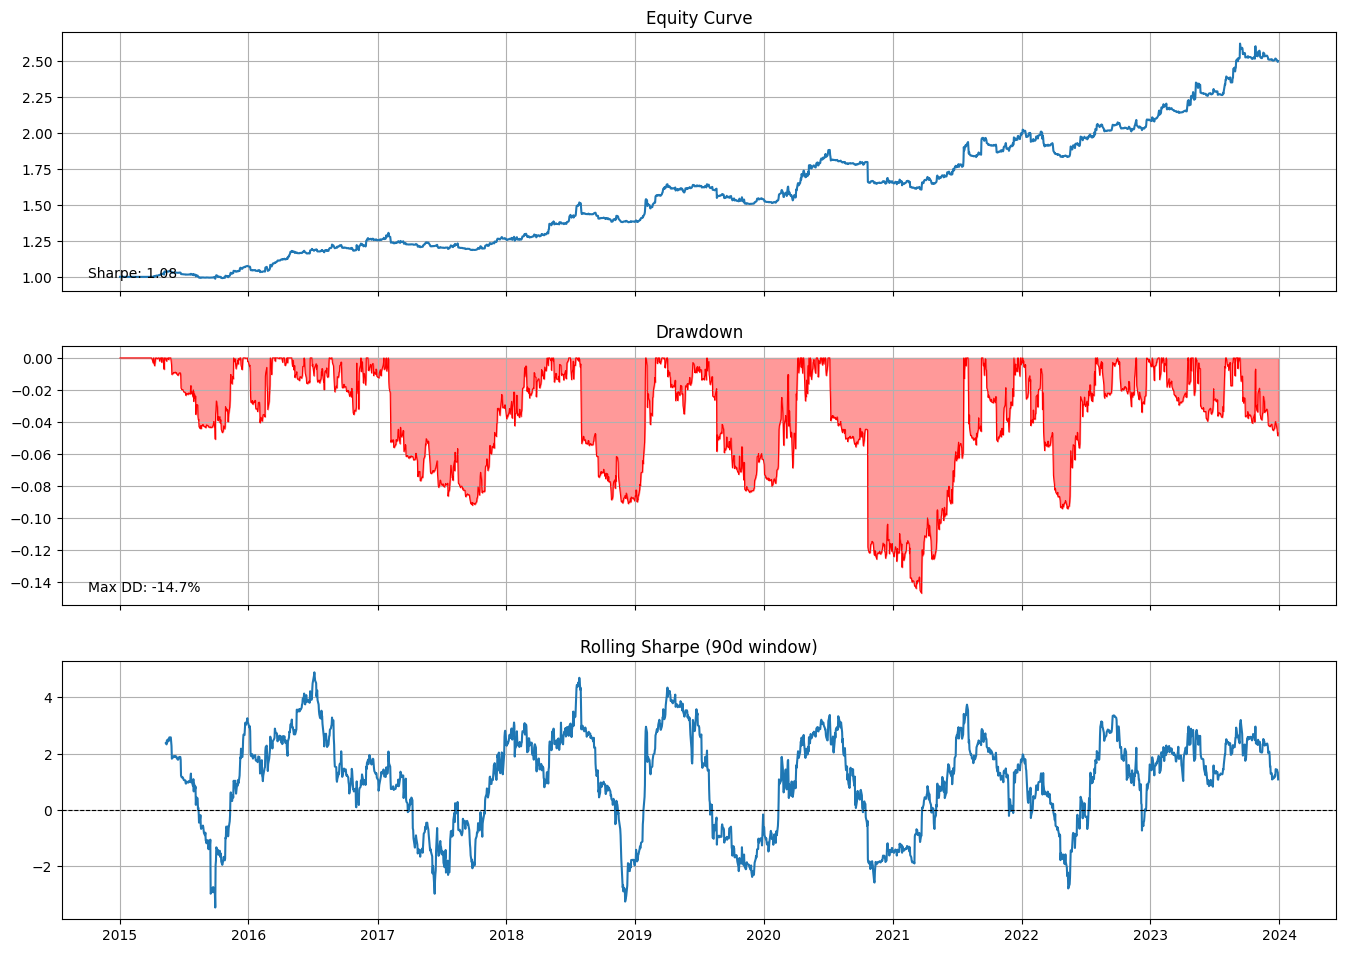

Study(name='resid_mr_v10_slow_benchmark_regime', steps=['base_signal', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'position_builder', 'position_scaler', 'position_scaler', 'position_scaler'], weighting=False, ran=True)

In [5]:
study.report()